In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

file_path=r'D:\Telecom churn prediction\data\raw\telecom_churn.csv'
data=pd.read_csv(file_path)

print("First 5 rows of the dataset:")
print(data.head())

# Summary statistics
print("\nSummary Statistics:")
print(data.describe())

# Data types and non-null counts
print("\nDataFrame Info:")
print(data.info())

First 5 rows of the dataset:
   customer_id telecom_partner gender  age              state     city  \
0            1    Reliance Jio      F   25          Karnataka  Kolkata   
1            2    Reliance Jio      F   55            Mizoram   Mumbai   
2            3        Vodafone      F   57  Arunachal Pradesh    Delhi   
3            4            BSNL      M   46         Tamil Nadu  Kolkata   
4            5            BSNL      F   26            Tripura    Delhi   

   pincode date_of_registration  num_dependents  estimated_salary  calls_made  \
0   755597           2020-01-01               4            124962          44   
1   125926           2020-01-01               2            130556          62   
2   423976           2020-01-01               0            148828          49   
3   522841           2020-01-01               1             38722          80   
4   740247           2020-01-01               2             55098          78   

   sms_sent  data_used  churn  
0      

In [2]:
# Data preprocessing
print(data.isnull().sum()) # no missing values
print(data.duplicated().sum())
if data.duplicated().sum() > 0 :
    data =data.drop_duplicates()
    

customer_id             0
telecom_partner         0
gender                  0
age                     0
state                   0
city                    0
pincode                 0
date_of_registration    0
num_dependents          0
estimated_salary        0
calls_made              0
sms_sent                0
data_used               0
churn                   0
dtype: int64
0


In [3]:
data['date_of_registration']=pd.to_datetime(data['date_of_registration'],errors='coerce')
print("Data types after conversion:\n", data.dtypes)

Data types after conversion:
 customer_id                      int64
telecom_partner                 object
gender                          object
age                              int64
state                           object
city                            object
pincode                          int64
date_of_registration    datetime64[ns]
num_dependents                   int64
estimated_salary                 int64
calls_made                       int64
sms_sent                         int64
data_used                        int64
churn                            int64
dtype: object


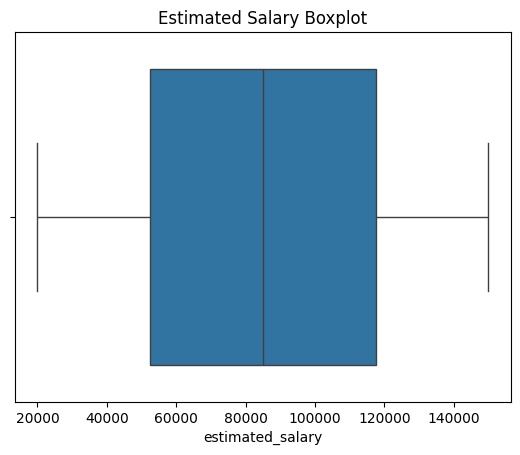

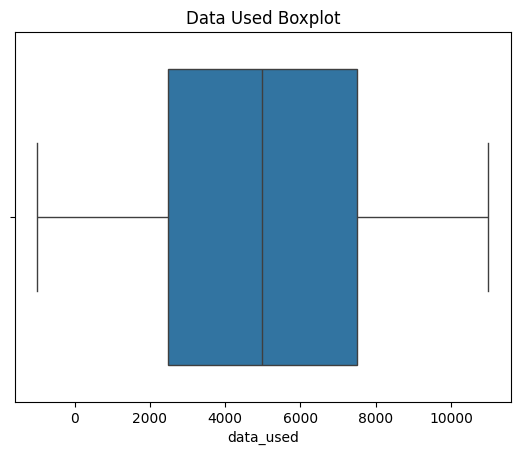

In [4]:
# Boxplot for 'estimated_salary' to visualize outliers
sns.boxplot(x=data['estimated_salary'])
plt.title('Estimated Salary Boxplot')
plt.show()

# Boxplot for 'data_used' to visualize outliers
sns.boxplot(x=data['data_used'])
plt.title('Data Used Boxplot')
plt.show()

In [5]:
#encoding categorical data
data=pd.get_dummies(data, columns=['telecom_partner','gender','state','city'],drop_first=True)
print(data.head())

   customer_id  age  pincode date_of_registration  num_dependents  \
0            1   25   755597           2020-01-01               4   
1            2   55   125926           2020-01-01               2   
2            3   57   423976           2020-01-01               0   
3            4   46   522841           2020-01-01               1   
4            5   26   740247           2020-01-01               2   

   estimated_salary  calls_made  sms_sent  data_used  churn  ...  \
0            124962          44        45       -361      0  ...   
1            130556          62        39       5973      0  ...   
2            148828          49        24        193      1  ...   
3             38722          80        25       9377      1  ...   
4             55098          78        15       1393      0  ...   

   state_Telangana  state_Tripura  state_Uttar Pradesh  state_Uttarakhand  \
0            False          False                False              False   
1            False    

In [6]:
#scaling numerical feature

from sklearn.preprocessing import StandardScaler

numerical_cols=['age','estimated_salary','calls_made','sms_sent','data_used']
scaler=StandardScaler()
data[numerical_cols]=scaler.fit_transform(data[numerical_cols])
print(data[numerical_cols].head())

        age  estimated_salary  calls_made  sms_sent  data_used
0 -1.281782          1.064837   -0.170117  1.429025  -1.819905
1  0.542593          1.213975    0.441016  1.021791   0.333042
2  0.664218          1.701113   -0.000358  0.003706  -1.631599
3 -0.004720         -1.234351    1.052149  0.071578   1.490073
4 -1.220969         -0.797761    0.984245 -0.607145  -1.223715


In [7]:
#train test split

from sklearn.model_selection import train_test_split

X=data.drop(columns=['customer_id','churn'])
y=data['churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print(X_train.shape,X_test.shape)

(170487, 44) (73066, 44)


In [8]:
plt.style.use('default')
sns.set_palette('viridis')


Churn Value Counts:
churn
0    194726
1     48827
Name: count, dtype: int64


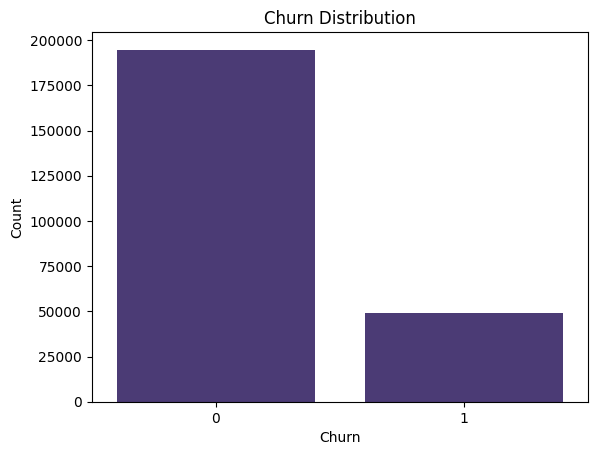

In [9]:

# Check the target variable (churn) distribution
print("Churn Value Counts:")
print(data['churn'].value_counts())
sns.countplot(x='churn', data=data)
plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.show()

In [10]:
# Calculate churn rate
churn_rate = data['churn'].mean()
print(f"Churn Rate: {churn_rate:.2%}")

Churn Rate: 20.05%


There was an error in column names. These categorical variables were hot-encoded means sub-divided and merged into their values increasing the number of columns(gender_M, gender_F etc.). So from here, I decided to feature those categorical variables separately for as 'sns.barplot' can't be used to plot bars together.

C:\Users\hp\AppData\Local\Temp\ipykernel_21344\4289177832.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  churn_rates[feature] = data.groupby(feature)['churn'].mean()[1]  # Churn rate where feature = 1


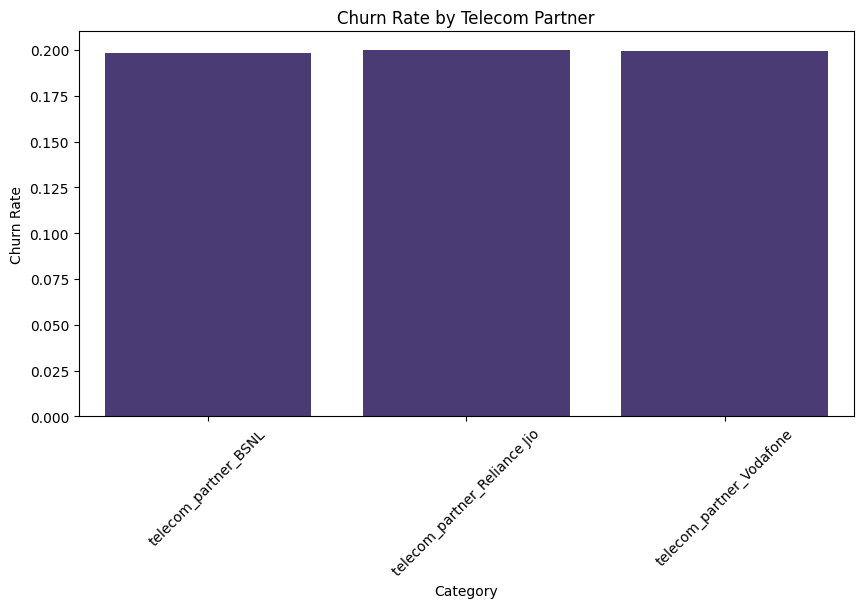

C:\Users\hp\AppData\Local\Temp\ipykernel_21344\4289177832.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  churn_rates[feature] = data.groupby(feature)['churn'].mean()[1]  # Churn rate where feature = 1


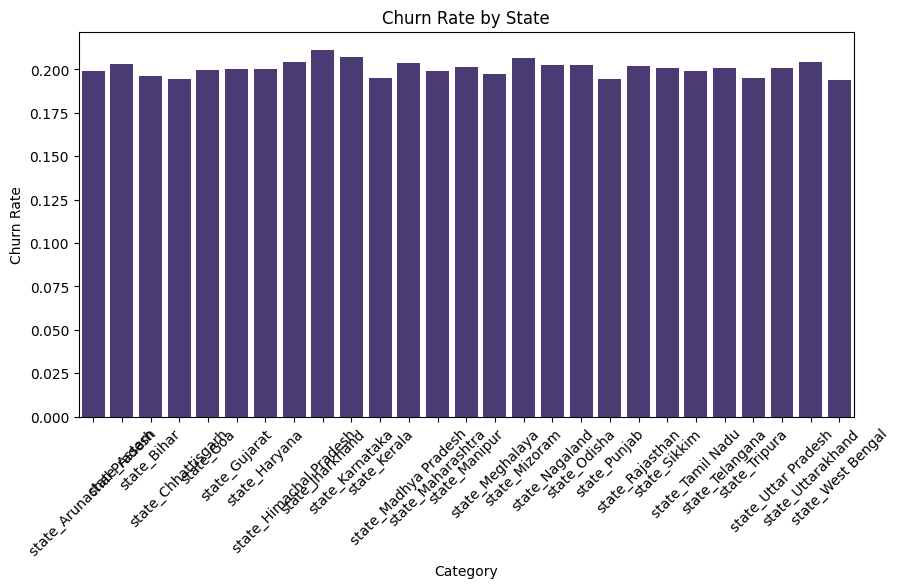

C:\Users\hp\AppData\Local\Temp\ipykernel_21344\4289177832.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  churn_rates[feature] = data.groupby(feature)['churn'].mean()[1]  # Churn rate where feature = 1


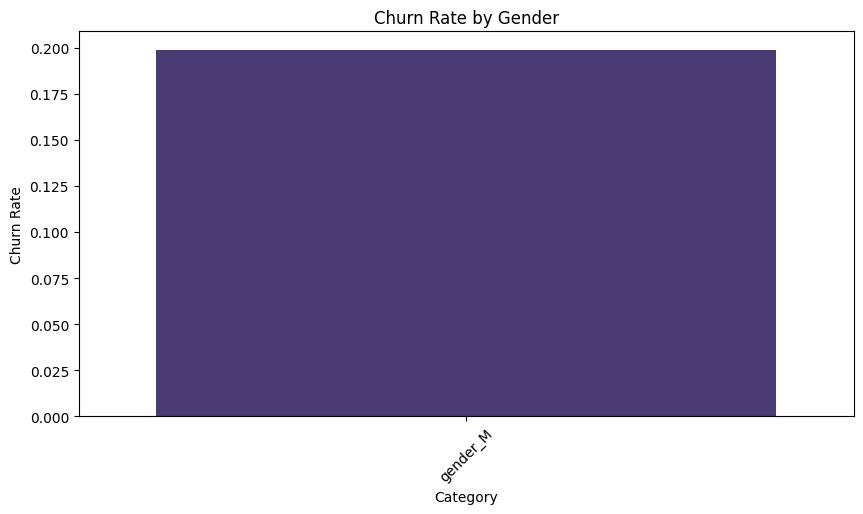

In [11]:
# Fix categorical feature names
categorical_features = ['telecom_partner_BSNL', 'telecom_partner_Reliance Jio', 'telecom_partner_Vodafone']
state_features = [col for col in data.columns if col.startswith('state_')]
gender_features = ['gender_M']  # Since 'gender_F' would be redundant

# Function to plot churn rate for one-hot encoded categorical features
def plot_churn_rate(feature_list, title):
    churn_rates = {}
    for feature in feature_list:
        churn_rates[feature] = data.groupby(feature)['churn'].mean()[1]  # Churn rate where feature = 1

    plt.figure(figsize=(10, 5))
    sns.barplot(x=list(churn_rates.keys()), y=list(churn_rates.values()))
    plt.title(title)
    plt.xlabel('Category')
    plt.ylabel('Churn Rate')
    plt.xticks(rotation=45)
    plt.show()

# Plot churn rates for each categorical feature
plot_churn_rate(categorical_features, "Churn Rate by Telecom Partner")
plot_churn_rate(state_features, "Churn Rate by State")
plot_churn_rate(gender_features, "Churn Rate by Gender")

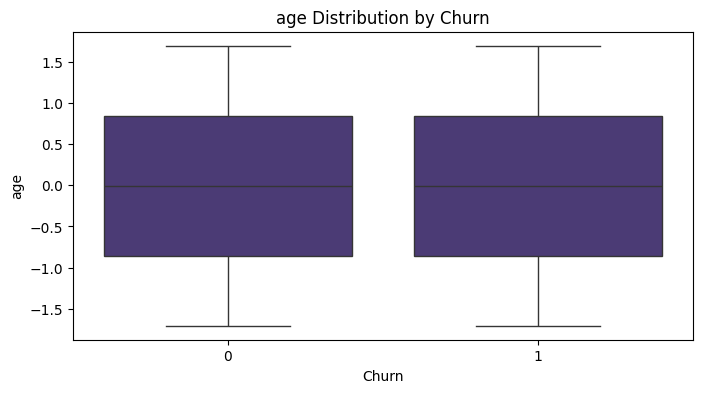

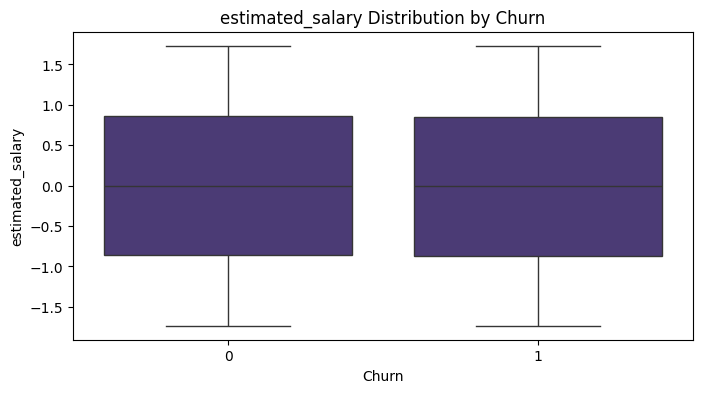

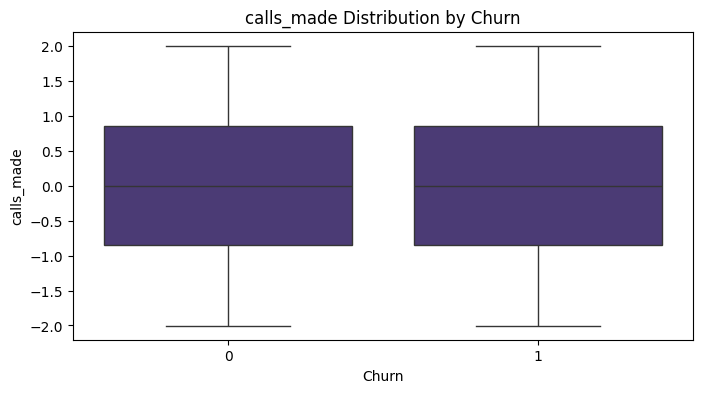

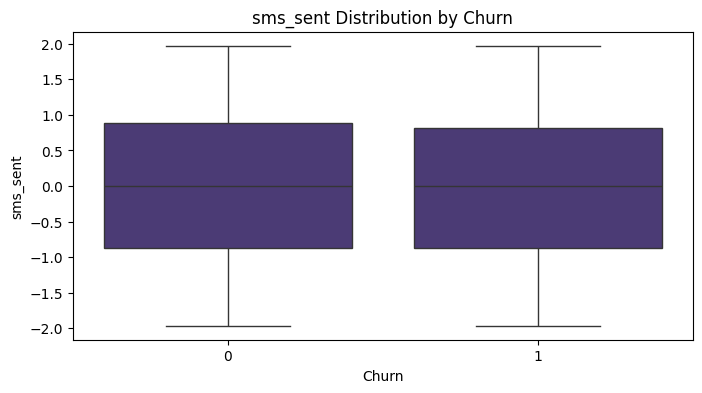

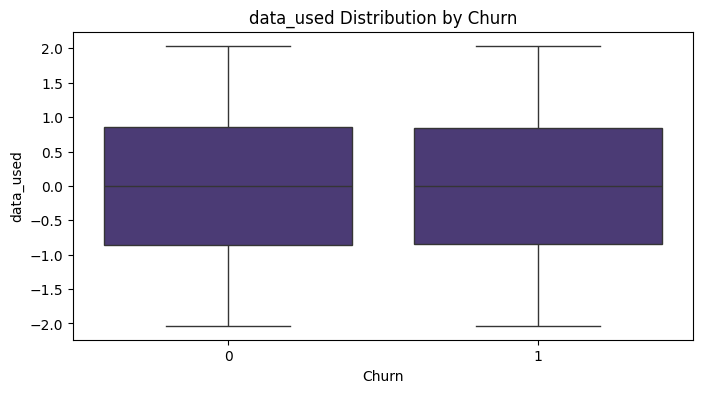

In [12]:
#Analyzing numerical feature

numerical_features = ['age','estimated_salary', 'calls_made', 'sms_sent', 'data_used']
for feature in numerical_features:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=data['churn'], y=data[feature])
    plt.title(f'{feature} Distribution by Churn')
    plt.xlabel('Churn')
    plt.ylabel(feature)
    plt.show()

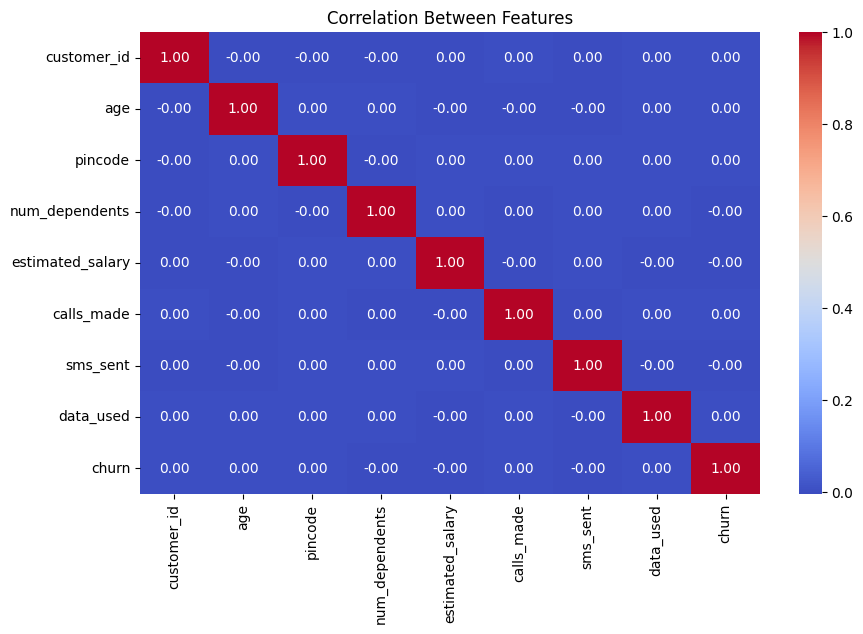

In [13]:
#correlation analysis of numerical feature

plt.figure(figsize=(10, 6))
sns.heatmap(data.select_dtypes(include=['number']).corr(), annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title('Correlation Between Features')
plt.show()

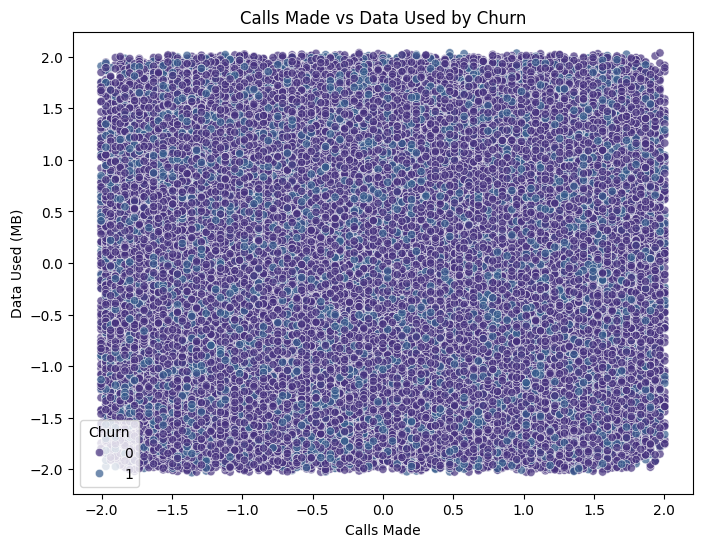

In [14]:
# Scatter plot for two numerical features
plt.figure(figsize=(8, 6))
sns.scatterplot(x='calls_made', y='data_used', hue='churn', data=data, alpha=0.7)
plt.title('Calls Made vs Data Used by Churn')
plt.xlabel('Calls Made')
plt.ylabel('Data Used (MB)')
plt.legend(title='Churn', loc='best')
plt.show()

In [15]:
missing_values=data.isnull().sum()
print("missing_values in each column:/n",missing_values[missing_values>0])

missing_values in each column:/n Series([], dtype: int64)


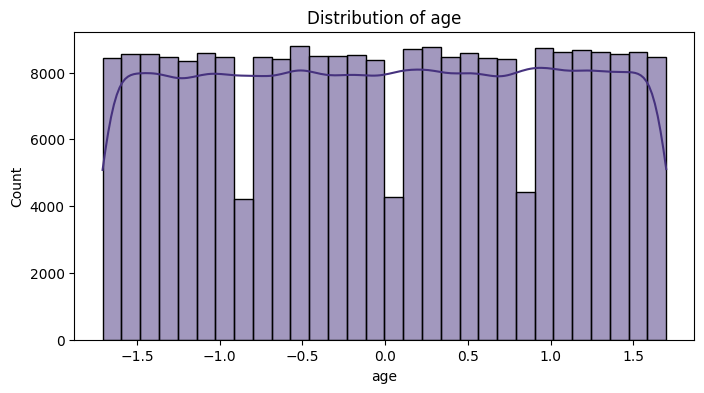

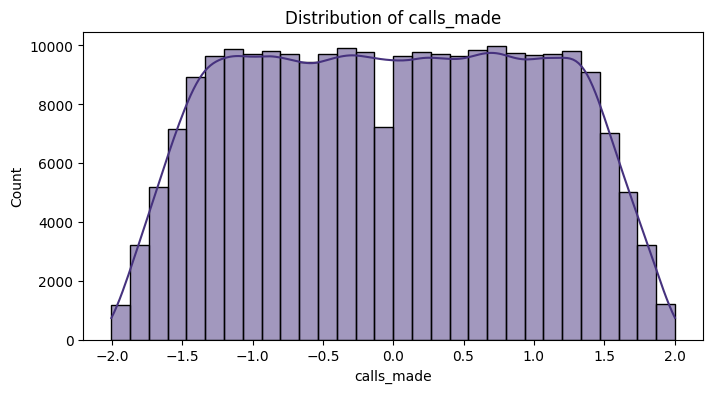

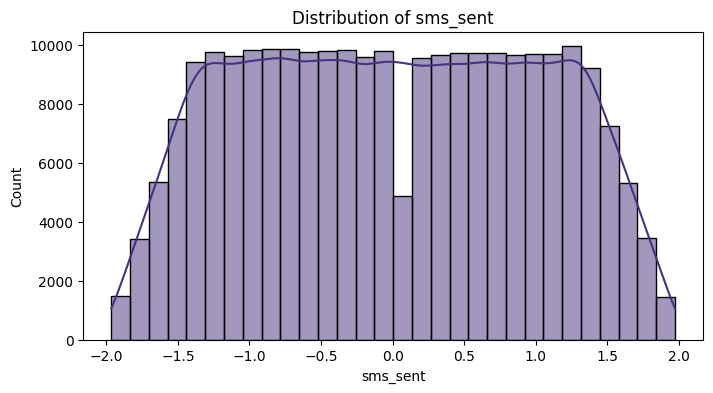

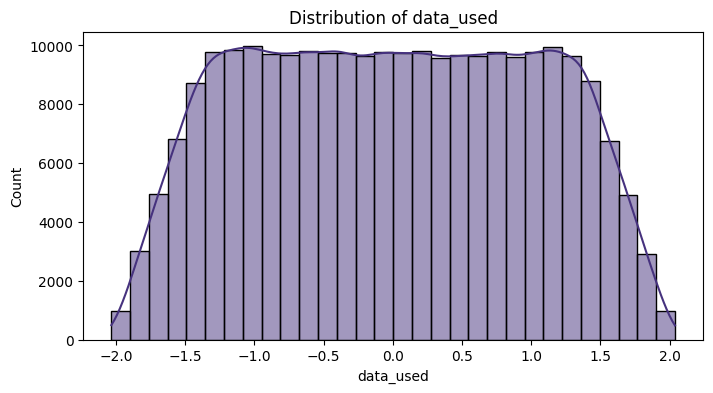

In [16]:
# Distribution of numerical features
numerical_features = ['age', 'calls_made', 'sms_sent', 'data_used']
for feature in numerical_features:
    plt.figure(figsize=(8, 4))
    sns.histplot(data[feature], kde=True, bins=30)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.show()

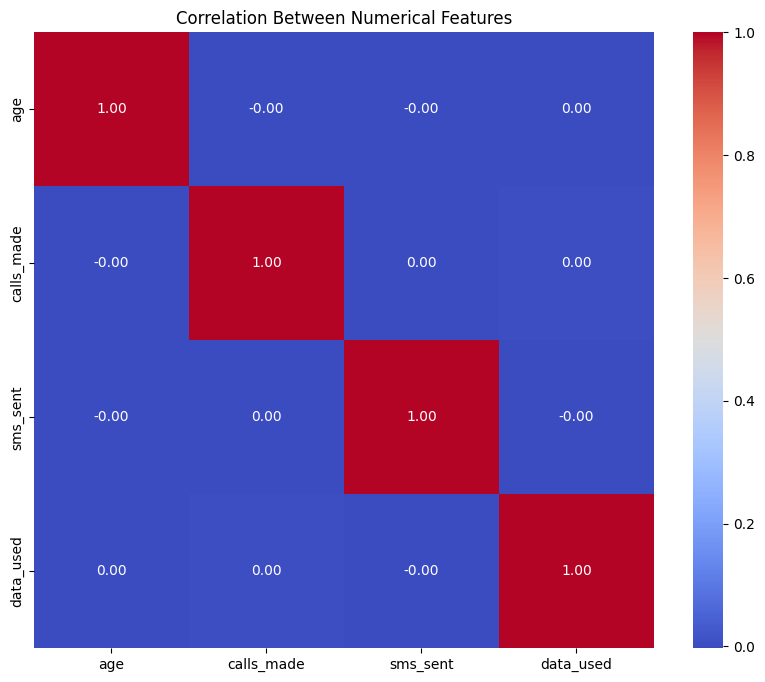

In [17]:
# Check for multicollinearity
plt.figure(figsize=(10, 8))
sns.heatmap(data[numerical_features].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Between Numerical Features')
plt.show()


In [18]:
# Creating interaction features
data['call_sms_ratio'] = data['calls_made'] / (data['sms_sent'] + 1)  
data['data_per_call'] = data['data_used'] / (data['calls_made'] + 1)  


In [19]:
# Convert date_of_registration to datetime format
data['date_of_registration'] = pd.to_datetime(data['date_of_registration'])

# Compute the number of days since registration
data['days_since_registration'] = (pd.to_datetime('today') - data['date_of_registration']).dt.days


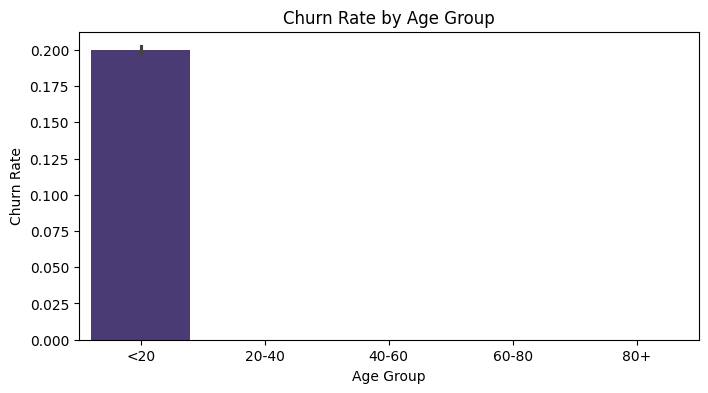

In [20]:
# Binning Age into categories
data['age_group'] = pd.cut(data['age'], bins=[0, 20, 40, 60, 80, 100], labels=['<20', '20-40', '40-60', '60-80', '80+'])

# Visualizing Age Group Churn Rate
plt.figure(figsize=(8, 4))
sns.barplot(x='age_group', y='churn', data=data)
plt.title('Churn Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Churn Rate')
plt.show()


In [21]:
# Checking variance of numerical features (excluding datetime columns)
low_variance_features = data.select_dtypes(include=['number']).var(numeric_only=True)
low_variance_features = low_variance_features[low_variance_features < 0.01].index

print("Low Variance Features:", low_variance_features.tolist())

# Dropping low variance features
data = data.drop(columns=low_variance_features)


Low Variance Features: []


In [22]:
# Compute correlation matrix
corr_matrix = data.select_dtypes(include=['number']).corr()

# Find pairs of highly correlated features
threshold = 0.85  # Adjust as needed
high_corr_features = set()

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > threshold:
            colname = corr_matrix.columns[i]
            high_corr_features.add(colname)

print("Highly Correlated Features to Drop:", high_corr_features)

# Drop the redundant features
data = data.drop(columns=high_corr_features)


Highly Correlated Features to Drop: {'days_since_registration'}


In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
numerical_features = data.select_dtypes(include=['number']).columns
data[numerical_features] = scaler.fit_transform(data[numerical_features])

print("Numerical features scaled successfully!")


Numerical features scaled successfully!


Preprocessing Stage

In [24]:
# checking multicollinearity by calculating vif
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

X = data[numerical_features]

vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# Display VIF values
print(vif_data)


             Feature       VIF
0        customer_id  1.000041
1                age  1.000033
2            pincode  1.000045
3     num_dependents  1.000057
4   estimated_salary  1.000061
5         calls_made  1.004783
6           sms_sent  1.000042
7          data_used  1.003699
8              churn  1.000035
9     call_sms_ratio  1.004804
10     data_per_call  1.003706


In [25]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = data.drop(columns=['churn'])  # Drop target variable
y = data['churn']

# Split into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Data split into training and testing sets successfully!")


Data split into training and testing sets successfully!


In [26]:
# casting DateTimeArray to dtype float32 because RandomForestClassifier does not support it directly
#converting datetime to numerical feature

datetime_cols = X_train.select_dtypes(include=['datetime64']).columns
print("Datetime Columns:", datetime_cols.tolist())

for col in datetime_cols:
    X_train[col + '_year'] = X_train[col].dt.year
    X_train[col + '_month'] = X_train[col].dt.month
    X_train[col + '_day'] = X_train[col].dt.day
    X_train[col + '_hour'] = X_train[col].dt.hour  # If time is important

    X_test[col + '_year'] = X_test[col].dt.year
    X_test[col + '_month'] = X_test[col].dt.month
    X_test[col + '_day'] = X_test[col].dt.day
    X_test[col + '_hour'] = X_test[col].dt.hour

# Drop original datetime columns
X_train = X_train.drop(columns=datetime_cols)
X_test = X_test.drop(columns=datetime_cols)


Datetime Columns: ['date_of_registration']


In [27]:
#converting non-numeric values

non_numeric_cols=X_train.select_dtypes(include=['object','category']).columns
print("non-numeric cols:",non_numeric_cols.tolist())

X_train = pd.get_dummies(X_train, columns=non_numeric_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=non_numeric_cols, drop_first=True)


non-numeric cols: ['age_group']


In [28]:
print(y_train.unique())
print(y_train.dtype)

[-0.50074665  1.99701787]
float64


In [29]:
from sklearn.ensemble import RandomForestRegressor

rf_regressor=RandomForestRegressor(n_estimators=100, random_state=42)
rf_regressor.fit(X_train,y_train)
print("Trained successfully")


Trained successfully


In [30]:
y_train = y_train.astype(int)  # Convert to integer labels
y_test = y_test.astype(int)


In [31]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
print("Random Forest Classifier trained successfully!")


Random Forest Classifier trained successfully!


In [32]:
X_train.to_csv("X_train.csv", index=False)
X_test.to_csv("X_test.csv", index=False)
y_train.to_csv("y_train.csv", index=False)
y_test.to_csv("y_test.csv", index=False)

print("Preprocessed data saved successfully!")


Preprocessed data saved successfully!


In [33]:
import joblib
#rf_model is rf_classifier model

joblib.dump(rf_model, "random_forest_classifier.pkl")

joblib.dump(rf_regressor, "random_forest_regressor.pkl")

print("Models saved successfully!")


Models saved successfully!


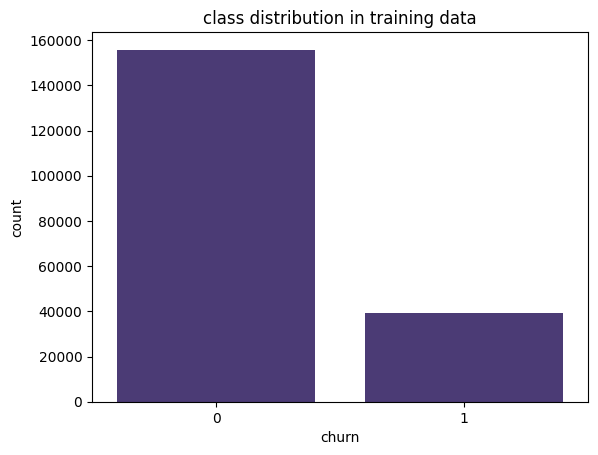

In [34]:
sns.countplot(x=y_train)
plt.title('class distribution in training data')
plt.show()

In [36]:
param_grid = {
    'n_estimators': [50, 100], 
    'max_depth': [None, 10],  
    'min_samples_split': [2, 5],  
    'min_samples_leaf': [1, 2]  
}


In [37]:
print(X_train.shape, y_train.shape)

(194842, 54) (194842,)


In [38]:
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

param_dist = {
    'n_estimators': np.arange(50, 200, 50),  
    'max_depth': [None, 10, 20],  
    'min_samples_split': [2, 5, 10],  
    'min_samples_leaf': [1, 2, 4]  
}

random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(),
    param_distributions=param_dist,
    n_iter=10, 
    scoring='accuracy',
    cv=3,
    n_jobs=1,
    random_state=42
)
random_search.fit(X_train, y_train)


RandomizedSearchCV(cv=3, estimator=RandomForestClassifier(), n_jobs=1,
                   param_distributions={'max_depth': [None, 10, 20],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': array([ 50, 100, 150])},
                   random_state=42, scoring='accuracy')

In [40]:
X_train = X_train.to_numpy()
y_train = y_train.to_numpy().ravel() 


In [48]:
X_train = pd.read_csv(r"D:\Telecom churn prediction\notebooks\X_train.csv")
y_train = pd.read_csv(r"D:\Telecom churn prediction\notebooks\y_train.csv")


In [49]:
y_train = y_train.squeeze()  # Now y_train is a proper Series


In [50]:
from imblearn.over_sampling import SMOTE
from collections import Counter

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", Counter(y_train))
print("After SMOTE:", Counter(y_train_bal))


Before SMOTE: Counter({0: 155780, 1: 39062})
After SMOTE: Counter({0: 155780, 1: 155780})


In [51]:
X_train_bal = pd.DataFrame(X_train_bal, columns=X_train.columns)
y_train_bal = pd.Series(y_train_bal)  # Ensures it's a Series, not 2D array


In [44]:
rf_classifier = RandomForestClassifier(random_state=42)
rf_classifier.fit(X_train_bal, y_train_bal)


RandomForestClassifier(random_state=42)

In [52]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf_classifier = RandomForestClassifier(random_state=42)
rf_classifier.fit(X_train_bal, y_train_bal)

class_eval = rf_classifier.predict(X_test)

print("Classification Accuracy:", accuracy_score(y_test, class_eval))
print("Classification Report:\n", classification_report(y_test, class_eval))


Classification Accuracy: 0.7880971443821724
Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.98      0.88     38946
           1       0.19      0.02      0.03      9765

    accuracy                           0.79     48711
   macro avg       0.49      0.50      0.46     48711
weighted avg       0.68      0.79      0.71     48711



Checking XGBoost for same data

In [54]:
from xgboost import XGBClassifier

xgb_clf = XGBClassifier(random_state=42, scale_pos_weight=1.0, use_label_encoder=False, eval_metric='logloss')
xgb_clf.fit(X_train_bal, y_train_bal)

xgb_preds = xgb_clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, xgb_preds))
print("Report:\n", classification_report(y_test, xgb_preds))


c:\Users\hp\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:183: UserWarning: [00:15:36] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.7994908747510829
Report:
               precision    recall  f1-score   support

           0       0.80      1.00      0.89     38946
           1       0.00      0.00      0.00      9765

    accuracy                           0.80     48711
   macro avg       0.40      0.50      0.44     48711
weighted avg       0.64      0.80      0.71     48711



In [55]:
# Get predicted probabilities
y_probs = xgb_clf.predict_proba(X_test)[:, 1]

# Set custom threshold
threshold = 0.3
y_pred_thresh = (y_probs >= threshold).astype(int)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred_thresh))
print("Report:\n", classification_report(y_test, y_pred_thresh))


Accuracy: 0.6527683685409866
Report:
               precision    recall  f1-score   support

           0       0.80      0.76      0.78     38946
           1       0.20      0.24      0.22      9765

    accuracy                           0.65     48711
   macro avg       0.50      0.50      0.50     48711
weighted avg       0.68      0.65      0.66     48711



In [57]:
y_probs = xgb_clf.predict_proba(X_test)[:, 1]  # Probabilities for class 1


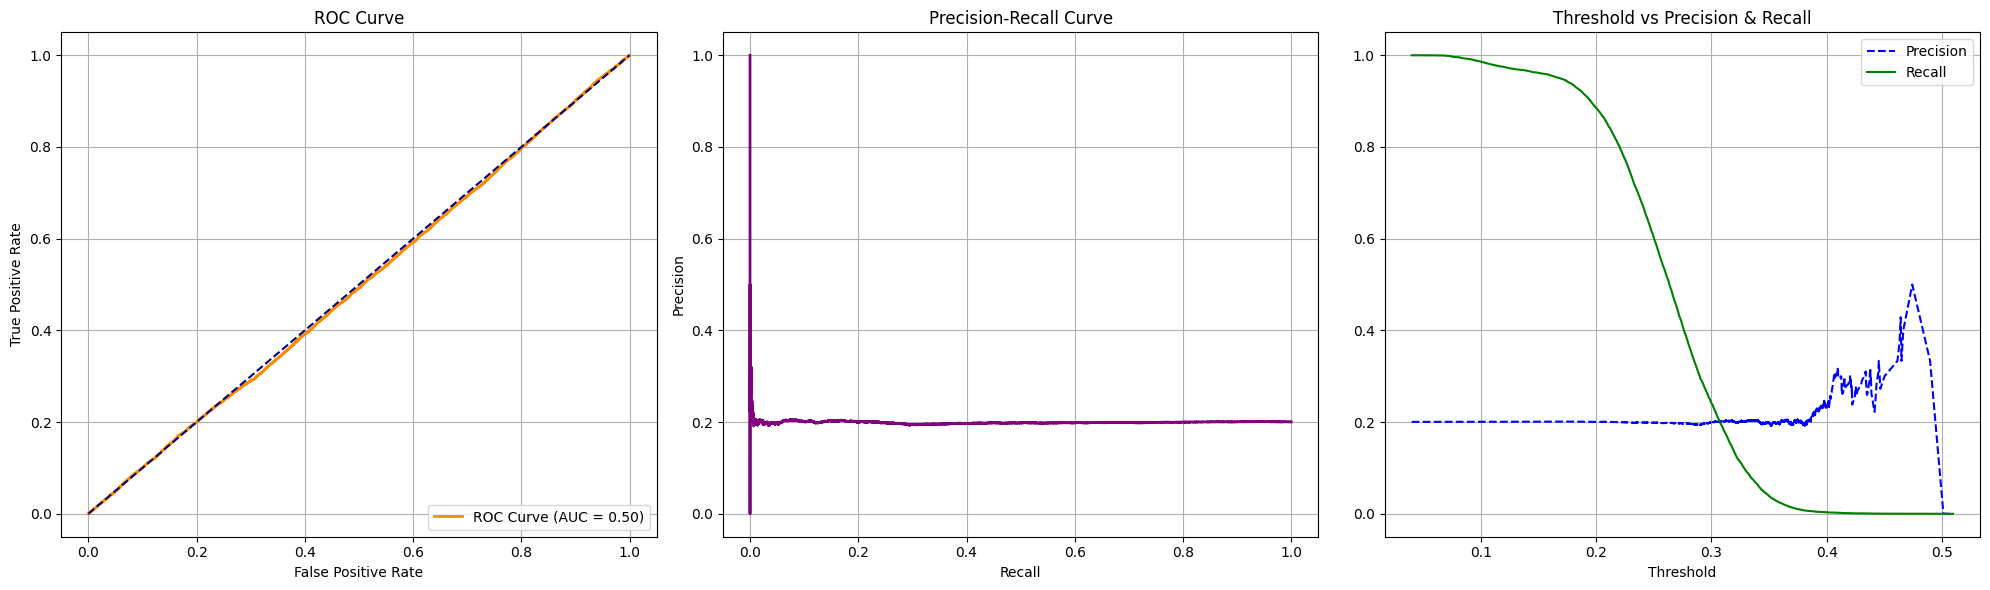

In [61]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve
import numpy as np

# 1. Get prediction probabilities
y_probs = xgb_clf.predict_proba(X_test)[:, 1]

# 2. ROC Curve
fpr, tpr, roc_thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

# 3. Precision-Recall Curve
precision, recall, pr_thresholds = precision_recall_curve(y_test, y_probs)

# Plot everything
plt.figure(figsize=(20, 6))

# ROC Curve
plt.subplot(1, 3, 1)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid()

# Precision-Recall Curve
plt.subplot(1, 3, 2)
plt.plot(recall, precision, color='purple', lw=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid()

# Threshold vs Precision & Recall
plt.subplot(1, 3, 3)
plt.plot(pr_thresholds, precision[:-1], 'b--', label='Precision')
plt.plot(pr_thresholds, recall[:-1], 'g-', label='Recall')
plt.xlabel('Threshold')
plt.title('Threshold vs Precision & Recall')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()


In [62]:
# 1. Get predicted probabilities instead of class labels
y_probs = xgb_clf.predict_proba(X_test)[:, 1]  # Probabilities for class '1'

# 2. Set a custom threshold (try between 0.3 - 0.4 for recall boost)
threshold = 0.35
y_pred_custom = (y_probs >= threshold).astype(int)

# 3. Evaluate the new predictions
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

print("Custom Threshold:", threshold)
print("Accuracy:", accuracy_score(y_test, y_pred_custom))
print("Precision:", precision_score(y_test, y_pred_custom))
print("Recall:", recall_score(y_test, y_pred_custom))
print("F1 Score:", f1_score(y_test, y_pred_custom))
print("\nClassification Report:\n", classification_report(y_test, y_pred_custom))


Custom Threshold: 0.35
Accuracy: 0.7756153640861407
Precision: 0.1974025974025974
Recall: 0.03891449052739376
F1 Score: 0.06501283147989735

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.96      0.87     38946
           1       0.20      0.04      0.07      9765

    accuracy                           0.78     48711
   macro avg       0.50      0.50      0.47     48711
weighted avg       0.68      0.78      0.71     48711



c:\Users\hp\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\hp\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\hp\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} i

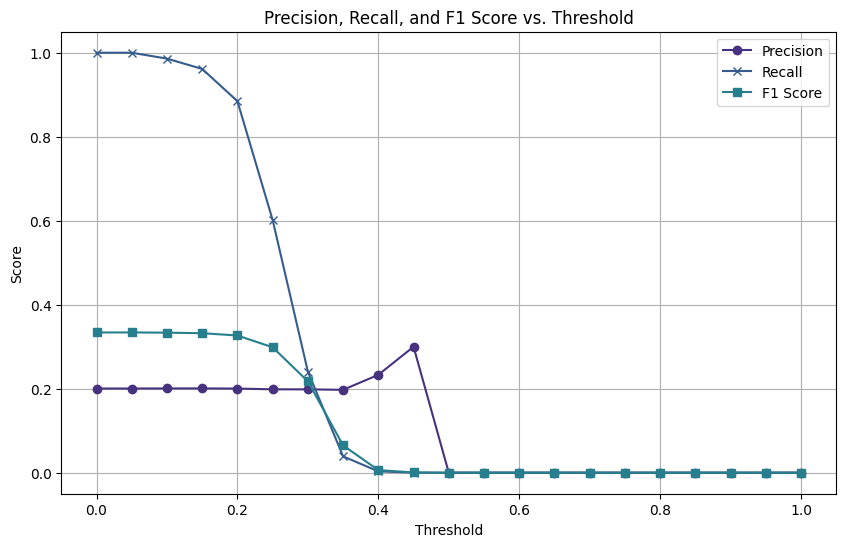

In [63]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.0, 1.01, 0.05)
precisions = []
recalls = []
f1s = []

for t in thresholds:
    y_pred_thresh = (y_probs >= t).astype(int)
    precisions.append(precision_score(y_test, y_pred_thresh))
    recalls.append(recall_score(y_test, y_pred_thresh))
    f1s.append(f1_score(y_test, y_pred_thresh))

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions, label='Precision', marker='o')
plt.plot(thresholds, recalls, label='Recall', marker='x')
plt.plot(thresholds, f1s, label='F1 Score', marker='s')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision, Recall, and F1 Score vs. Threshold')
plt.legend()
plt.grid(True)
plt.show()


In [64]:
best_threshold = 0.2  # try changing to 0.25 too
y_pred_best = (y_probs >= best_threshold).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred_best))
print("Precision:", precision_score(y_test, y_pred_best))
print("Recall:", recall_score(y_test, y_pred_best))
print("F1 Score:", f1_score(y_test, y_pred_best))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best))


Accuracy: 0.26905627065755167
Precision: 0.2003571594229788
Recall: 0.8846902201740912
F1 Score: 0.32672125257644236

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.11      0.20     38946
           1       0.20      0.88      0.33      9765

    accuracy                           0.27     48711
   macro avg       0.50      0.50      0.26     48711
weighted avg       0.68      0.27      0.23     48711

